# Multi-receptor integration with CARNIVAL

The original CARNIVAL method supports linking multiple receptors to TFs. However, one frequent problem is that CARNIVAL can select a single receptor to connect as many TFs as possible, ignoring the other provided TFs. Even though CORNETO adds specific options to extend CARNIVAL to penalize the depth of trees, which will encourage use of other receptors, in many cases this indirect way is not enough.

Since CORNETO provides a multi-sample CARNIVAL version, we can model the problem where every receptor is a single sample instead. In that case, the joint regularization (lambda > 0) will enforce similarity across the trees that link each receptor to  TFs. This provides an optimal strategy for finding the smallest union graph that contains the signalling trees from receptors to TFs.

Installed version: v1.0.0rc1
Available backends: CVXPY v1.7.1
Default backend (corneto.opt): CVXPY
Installed solvers: CLARABEL, GUROBI, HIGHS, OSQP, SCIPY, SCS
Plot backend (default): auto -> graphviz
Available plot backends: graphviz v0.21; graphviz-wasm
Installed path: <corneto-repository>/docs/tutorials/carnival/.pixi/envs/default/lib/python3.11/site-packages/corneto
Repository: https://github.com/saezlab/corneto
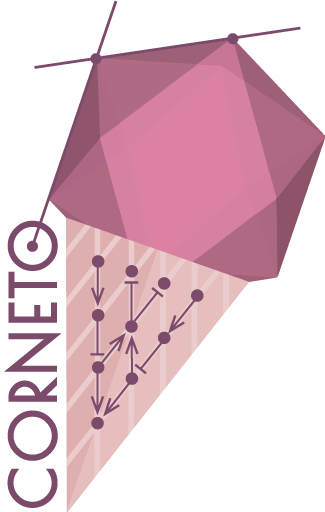

In [1]:
import corneto as cn
import numpy as np

cn.info()

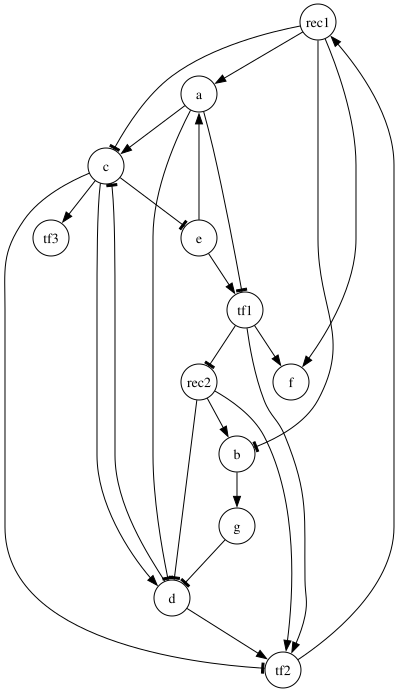

In [2]:
from corneto.graph import Graph

G = Graph.from_tuples(
    [
        ("rec1", 1, "a"),
        ("rec1", -1, "b"),
        ("rec1", 1, "f"),
        ("rec1", -1, "c"),
        ("rec2", 1, "b"),
        ("rec2", 1, "tf2"),
        ("b", 1, "g"),
        ("g", -1, "d"),
        ("rec2", -1, "d"),
        ("a", 1, "c"),
        ("a", -1, "d"),
        ("c", 1, "d"),
        ("c", -1, "e"),
        ("c", 1, "tf3"),
        ("e", 1, "a"),
        ("d", -1, "c"),
        ("e", 1, "tf1"),
        ("a", -1, "tf1"),
        ("d", 1, "tf2"),
        ("c", -1, "tf2"),
        ("tf1", 1, "tf2"),
        ("tf1", -1, "rec2"),
        ("tf2", 1, "rec1"),
        ("tf1", 1, "f"),
    ]
)
# Plot our PKN
G.plot()

In [3]:
from corneto.methods.carnival import CarnivalFlow

samples = {
    "receptor1_sample": {
        "rec1": {"value": 1, "mapping": "vertex", "role": "input"},
        "tf2": {"value": 1, "mapping": "vertex", "role": "output"},
    },
    "receptor2_sample": {
        "rec2": {"value": -1, "mapping": "vertex", "role": "input"},
        "tf1": {"value": 1, "mapping": "vertex", "role": "output"},
        "tf2": {"value": 1, "mapping": "vertex", "role": "output"},
    },
}

data = cn.Data.from_cdict(samples)
data

Data(n_samples=2, n_feats=[2 3])

In [4]:
c = CarnivalFlow(lambda_reg=1e-3)
P = c.build(G, data)
P.solve(verbosity=0, solver="scipy")

for o in P.objectives:
    print(o.value)

Unreachable vertices for sample: 0
Unreachable vertices for sample: 0
0.0
0.0
8.0


In [5]:
P.expr

{'_flow': _flow: Variable((25,), _flow),
 'edge_inhibits': edge_inhibits: Variable((25, 2), edge_inhibits, boolean=True),
 'edge_activates': edge_activates: Variable((25, 2), edge_activates, boolean=True),
 'const0x14df77c05f4ea025': const0x14df77c05f4ea025: Constant(CONSTANT, NONNEGATIVE, (10, 25)),
 '_dag_layer': _dag_layer: Variable((10, 2), _dag_layer),
 'const0x19c99d63116ef5a0': const0x19c99d63116ef5a0: Constant(CONSTANT, NONNEGATIVE, (10, 25)),
 'edge_has_signal_OR': edge_has_signal_OR: Variable((25,), edge_has_signal_OR, boolean=True),
 'flow': _flow: Variable((25,), _flow),
 'vertex_value': Expression(AFFINE, UNKNOWN, (10, 2)),
 'vertex_activated': Expression(AFFINE, NONNEGATIVE, (10, 2)),
 'vertex_inhibited': Expression(AFFINE, NONNEGATIVE, (10, 2)),
 'edge_value': Expression(AFFINE, UNKNOWN, (25, 2)),
 'edge_has_signal': Expression(AFFINE, NONNEGATIVE, (25, 2)),
 'vertex_max_depth': _dag_layer: Variable((10, 2), _dag_layer)}

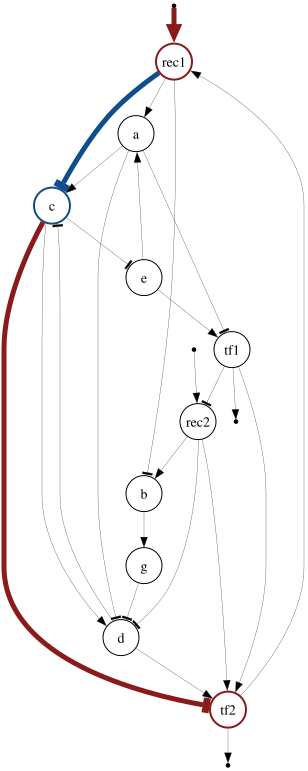

In [6]:
c.processed_graph.plot_values(vertex_values=P.expr.vertex_value.value[:, 0], edge_values=P.expr.edge_value.value[:, 0])

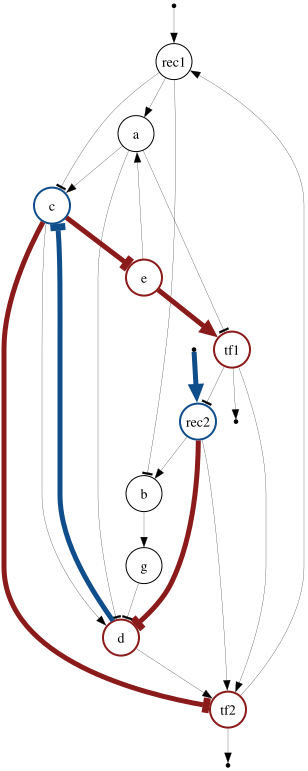

In [7]:
c.processed_graph.plot_values(vertex_values=P.expr.vertex_value.value[:, 1], edge_values=P.expr.edge_value.value[:, 1])

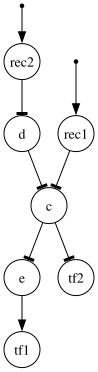

In [8]:
# Plot the union of the solutions
c.processed_graph.edge_subgraph(np.flatnonzero(P.expr.edge_has_signal_OR.value)).plot()

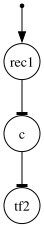

In [9]:
# Plot carnival tree for sample 1 (receptor 1)
c.processed_graph.edge_subgraph(np.flatnonzero(P.expr.edge_has_signal.value[:, 0])).plot()

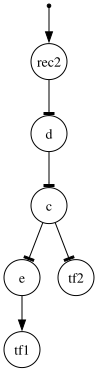

In [10]:
# Plot carnival  tree for sample 2 (receptor 2)
c.processed_graph.edge_subgraph(np.flatnonzero(P.expr.edge_has_signal.value[:, 1])).plot()